#  Sesión 02: Modelos de Clasificación II
## Ejercicio 3: Aplicación a Dataset Propio (Clasificación Binaria)
###  Caso de Estudio: Predicción de Rotación de Empleados (Employee Attrition)

- **Curso:** Ingeniería del Conocimiento (ISO56B)
- **Universidad:** Universidad Nacional del Centro del Perú (UNCP)
- **Periodo:** 2026-II
- **Docente:** Msc. Jaime Antonio Huaytalla Pariona
- **Estudiante:** Yimar Jesus Briceño Alaya

**Objetivo del Ejercicio:** Seleccionar un dataset propio (>500 registros, >5 features), aplicar los 4 modelos de clasificación vistos en clase (Regresión Logística, Árbol de Decisión, SVM, KNN) + 1 modelo adicional (Random Forest), y documentar métricas, curvas ROC, matriz de selección y la justificación del mejor modelo para la toma de decisiones.

CELDA 1: Configuración del Entorno

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier # Modelo extra requerido
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, roc_curve, auc
)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('✓ Librerías cargadas correctamente')

✓ Librerías cargadas correctamente


CELDA 2: Carga y Exploración del Dataset

In [83]:
import pandas as pd
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print(f' Dataset cargado: {df.shape[0]} empleados')
print(df['Attrition'].value_counts())


print('ESTADÍSTICAS DESCRIPTIVAS DEL DATASET')


# Mostrar estadísticas descriptivas (redondeado a 3 decimales)
display(df.describe().round(3))

print(f'\n Total de registros: {df.shape[0]}')
print(f' Total de columnas: {df.shape[1]}')
print(f'\n Observaciones:')
print(f'   • La edad promedio de los empleados es {df["Age"].mean():.1f} años')
print(f'   • El ingreso mensual promedio es ${df["MonthlyIncome"].mean():,.0f}')
print(f'   • La satisfacción laboral promedio es {df["JobSatisfaction"].mean():.2f} (escala 1-4)')
print(f'   • El tiempo promedio en la empresa es {df["YearsAtCompany"].mean():.1f} años')

 Dataset cargado: 1470 empleados
Attrition
0    1233
1     237
Name: count, dtype: int64
ESTADÍSTICAS DESCRIPTIVAS DEL DATASET


,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000,1470.000,1470.000,1470.000,1470.000,1470.0,1470.000,1470.000,1470.000,1470.000,...,1470.000,1470.0,1470.000,1470.000,1470.000,1470.000,1470.000,1470.000,1470.000,1470.000
mean,36.924,0.161,802.486,9.193,2.913,1.0,1024.865,2.722,65.891,2.730,...,2.712,80.0,0.794,11.280,2.799,2.761,7.008,4.229,2.188,4.123
std,9.135,0.368,403.509,8.107,1.024,0.0,602.024,1.093,20.329,0.712,...,1.081,0.0,0.852,7.781,1.289,0.706,6.127,3.623,3.222,3.568
min,18.000,0.000,102.000,1.000,1.000,1.0,1.000,1.000,30.000,1.000,...,1.000,80.0,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000
25%,30.000,0.000,465.000,2.000,2.000,1.0,491.250,2.000,48.000,2.000,...,2.000,80.0,0.000,6.000,2.000,2.000,3.000,2.000,0.000,2.000
50%,36.000,0.000,802.000,7.000,3.000,1.0,1020.500,3.000,66.000,3.000,...,3.000,80.0,1.000,10.000,3.000,3.000,5.000,3.000,1.000,3.000
75%,43.000,0.000,1157.000,14.000,4.000,1.0,1555.750,4.000,83.750,3.000,...,4.000,80.0,1.000,15.000,3.000,3.000,9.000,7.000,3.000,7.000
max,60.000,1.000,1499.000,29.000,5.000,1.0,2068.000,4.000,100.000,4.000,...,4.000,80.0,3.000,40.000,6.000,4.000,40.000,18.000,15.000,17.000



 Total de registros: 1470
 Total de columnas: 35

 Observaciones:
   • La edad promedio de los empleados es 36.9 años
   • El ingreso mensual promedio es $6,503
   • La satisfacción laboral promedio es 2.73 (escala 1-4)
   • El tiempo promedio en la empresa es 7.0 años


CELDA 3: Análisis Exploratorio

ANÁLISIS EXPLORATORIO ORIENTADO A CLASIFICACIÓN


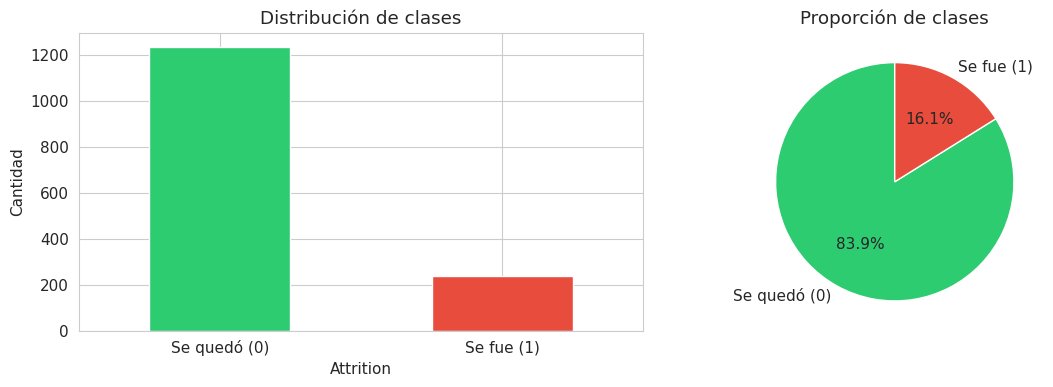

In [84]:

print('ANÁLISIS EXPLORATORIO ORIENTADO A CLASIFICACIÓN')


# 3.1 Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#e74c3c', '#2ecc71']  # Rojo: Se fue, Verde: Se quedó

df['Attrition'].map({1: 'Se fue (1)', 0: 'Se quedó (0)'}).value_counts().plot(
    kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c']
)
axes[0].set_title('Distribución de clases')
axes[0].set_ylabel('Cantidad')
axes[0].set_xticklabels(['Se quedó (0)', 'Se fue (1)'], rotation=0)

df['Attrition'].map({1: 'Se fue (1)', 0: 'Se quedó (0)'}).value_counts().plot(
    kind='pie', ax=axes[1], colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%', startangle=90
)
axes[1].set_ylabel('')
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()







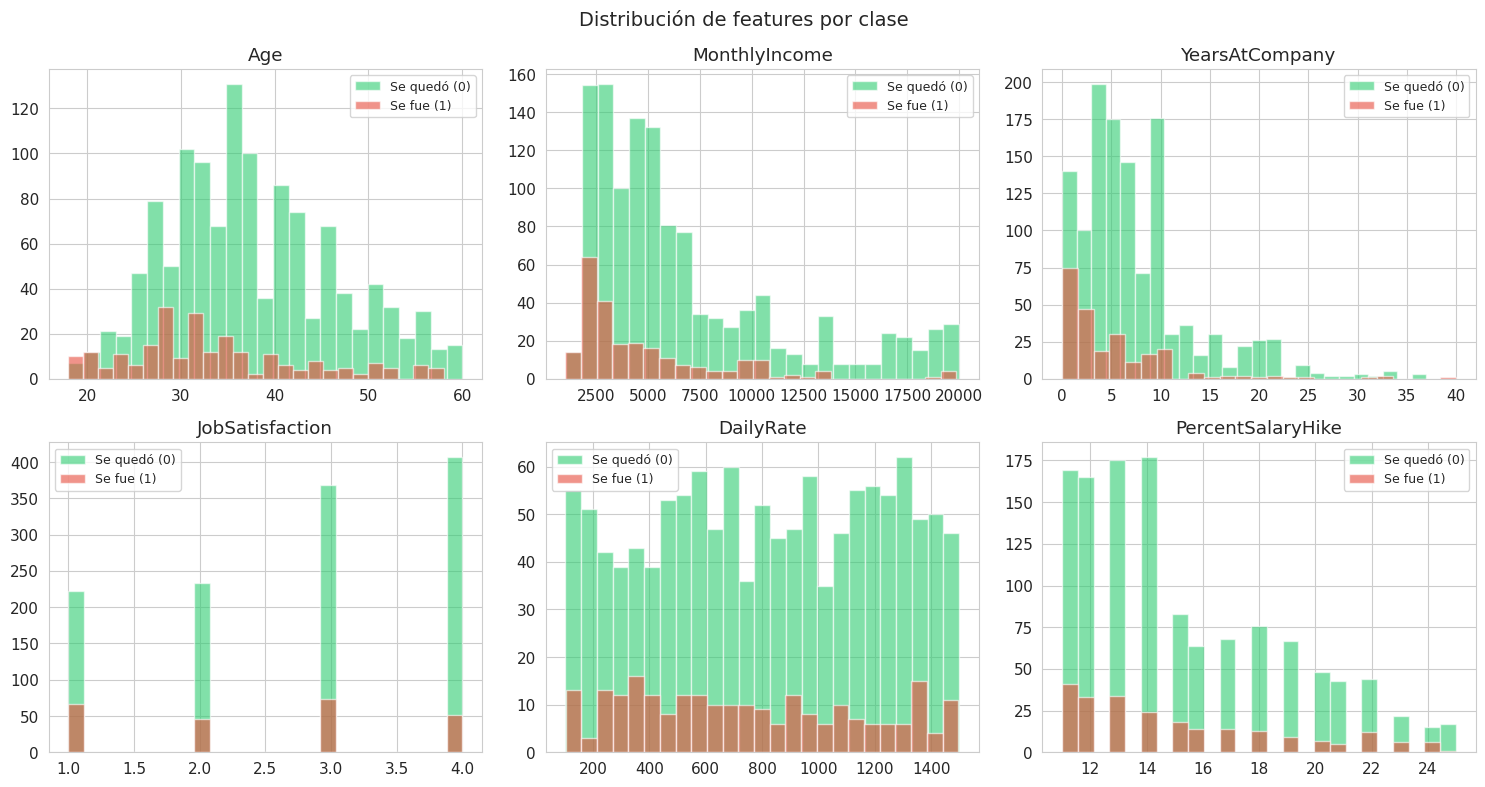

In [85]:
# 3.2 Distribución de features clave por clase
key_features = ['Age', 'MonthlyIncome', 'YearsAtCompany',
                'JobSatisfaction', 'DailyRate', 'PercentSalaryHike']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, feat in enumerate(key_features):
    ax = axes[i//3, i%3]
    for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
        subset = df[df['Attrition'] == label][feat]
        ax.hist(subset, bins=25, alpha=0.6, color=color,
                label='Se quedó (0)' if label == 0 else 'Se fue (1)')
    ax.set_title(feat)
    ax.legend(fontsize=9)

plt.suptitle('Distribución de features por clase', fontsize=14)
plt.tight_layout()
plt.show()

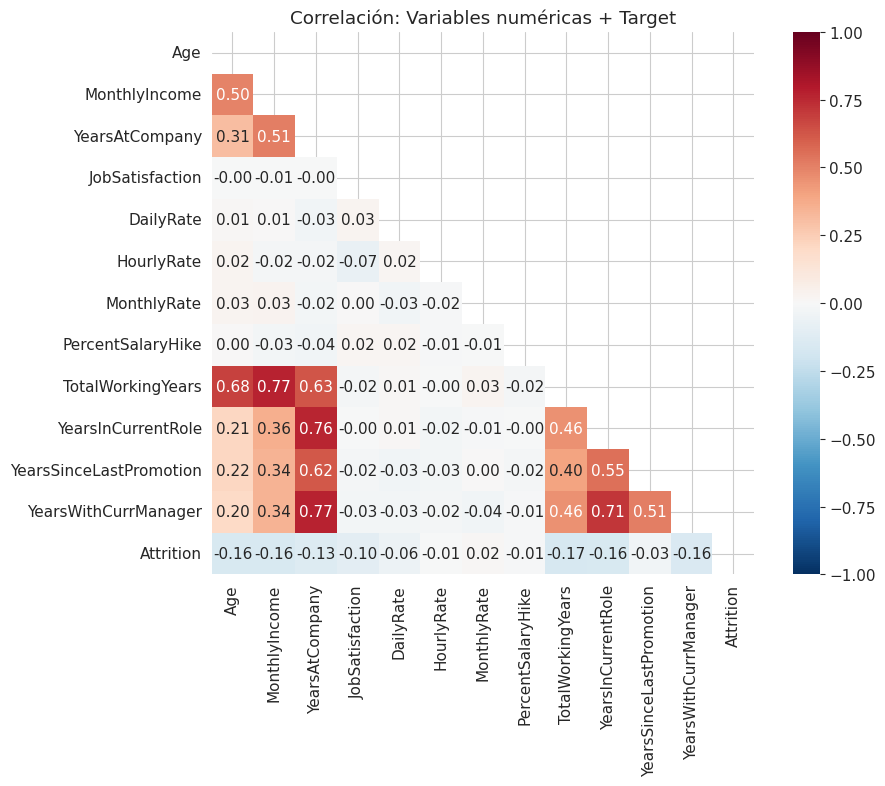

In [86]:
# 3.3 Matriz de correlación (variables numéricas clave)
num_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'JobSatisfaction',
            'DailyRate', 'HourlyRate', 'MonthlyRate', 'PercentSalaryHike',
            'TotalWorkingYears', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
            'YearsWithCurrManager', 'Attrition']

plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True)
plt.title('Correlación: Variables numéricas + Target')
plt.tight_layout()
plt.show()

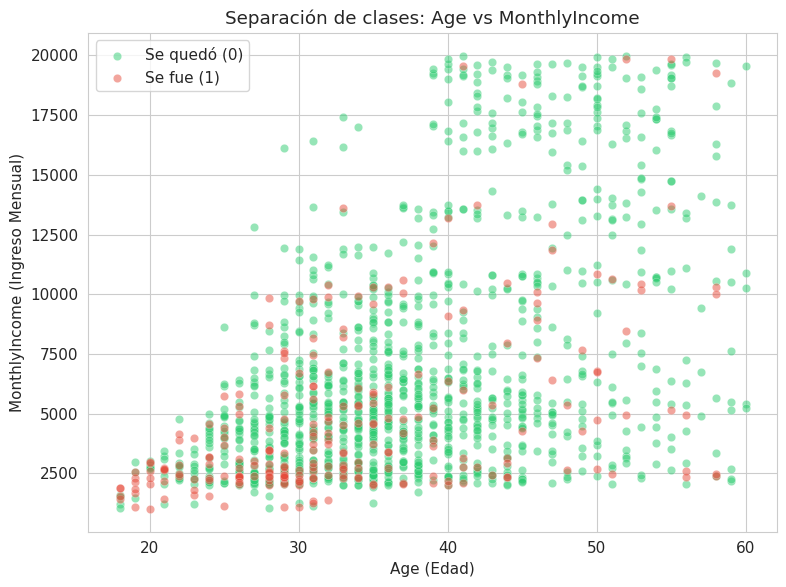

In [87]:
# 3.4 Scatter plot: 2 features más discriminativas
fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in zip([0, 1], ['#2ecc71', '#e74c3c'], ['Se quedó (0)', 'Se fue (1)']):
    mask = df['Attrition'] == label
    ax.scatter(df.loc[mask, 'Age'], df.loc[mask, 'MonthlyIncome'],
              alpha=0.5, c=color, label=name, edgecolors='w', linewidth=0.3)
ax.set_xlabel('Age (Edad)')
ax.set_ylabel('MonthlyIncome (Ingreso Mensual)')
ax.set_title('Separación de clases: Age vs MonthlyIncome')
ax.legend()
plt.tight_layout()
plt.show()

CELDA 4: Preparación de Datos

In [88]:
print('='*60)
print('PREPARACIÓN DE DATOS')
print('='*60)

# 1. Eliminar columnas que no aportan (IDs o constantes)
cols_to_drop = ['EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18', 'Attrition']
X = df.drop(columns=cols_to_drop).copy()
y = df['Attrition'].copy()

# 2. One-Hot Encoding para variables categóricas
X = pd.get_dummies(X, drop_first=True, dtype=int)

# 3. Train/Test Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} muestras, {X_train.shape[1]} features (tras One-Hot Encoding)')
print(f'Test:          {X_test.shape[0]} muestras')
print(f'\nProporción en train: {y_train.mean():.1%} se fueron')
print(f'Proporción en test:  {y_test.mean():.1%} se fueron')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

PREPARACIÓN DE DATOS
Entrenamiento: 1176 muestras, 44 features (tras One-Hot Encoding)
Test:          294 muestras

Proporción en train: 16.2% se fueron
Proporción en test:  16.0% se fueron


CELDA 5: Funciones Auxiliares de Evaluación

In [89]:
def eval_classifier(model, X_tr, y_tr, X_te, y_te, model_name='Modelo'):
    y_pred = model.predict(X_te)
    metrics = {
        'Accuracy':  accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall':    recall_score(y_te, y_pred),
        'F1-Score':  f1_score(y_te, y_pred)
    }
    print(f'=== {model_name} ===')
    for k, v in metrics.items(): print(f'  {k}: {v:.4f}')

    # Matriz de confusión
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=['Se quedó', 'Se fue'], yticklabels=['Se quedó', 'Se fue'])
    axes[0].set_title(f'Matriz de Confusión — {model_name}')

    tn, fp, fn, tp = cm.ravel()
    axes[1].bar(['TN', 'FP', 'FN', 'TP'], [tn, fp, fn, tp], color=['#2ecc71', '#f39c12', '#e74c3c', '#3498db'])
    axes[1].set_title(f'Desglose — {model_name}')
    plt.tight_layout()
    plt.show()
    return metrics

def plot_roc(model, X_te, y_te, model_name='Modelo', ax=None):
    if ax is None: fig, ax = plt.subplots(figsize=(6, 5))
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_te)[:, 1]
    else:
        y_score = model.decision_function(X_te)

    fpr, tpr, _ = roc_curve(y_te, y_score)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.set_title(f'Curva ROC — {model_name}')
    ax.legend()
    return roc_auc

CELDA 6: Entrenamiento de los 5 Modelos

MODELO 1


In [90]:

print('MODELO 1: REGRESIÓN LOGÍSTICA')


# 5.1 Pipeline con estandarización
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Validación cruzada estratificada
cv_lr = cross_validate(pipe_lr, X_train, y_train, cv=skf,
                       scoring=['accuracy', 'f1', 'recall'],
                       return_train_score=True)

print('Regresión Logística — Cross-Validation (5-fold)')
print(f'  Accuracy:  {cv_lr["test_accuracy"].mean():.4f} ± {cv_lr["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_lr["test_f1"].mean():.4f} ± {cv_lr["test_f1"].std():.4f}')
print(f'  Recall:    {cv_lr["test_recall"].mean():.4f} ± {cv_lr["test_recall"].std():.4f}')

# Entrenar modelo final
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

MODELO 1: REGRESIÓN LOGÍSTICA
Regresión Logística — Cross-Validation (5-fold)
  Accuracy:  0.8878 ± 0.0158
  F1-Score:  0.5552 ± 0.0884
  Recall:    0.4421 ± 0.0918


=== Regresión Logística ===
=== Regresión Logística ===
  Accuracy: 0.8605
  Precision: 0.6154
  Recall: 0.3404
  F1-Score: 0.4384


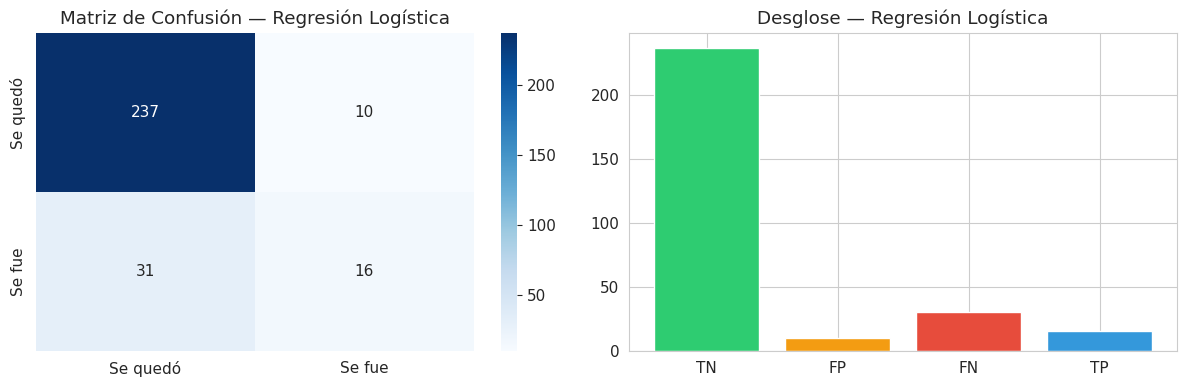

In [91]:
# 5.2 Evaluación completa
print('=== Regresión Logística ===')
metrics_lr = eval_classifier(pipe_lr, X_train, y_train, X_test, y_test, 'Regresión Logística')

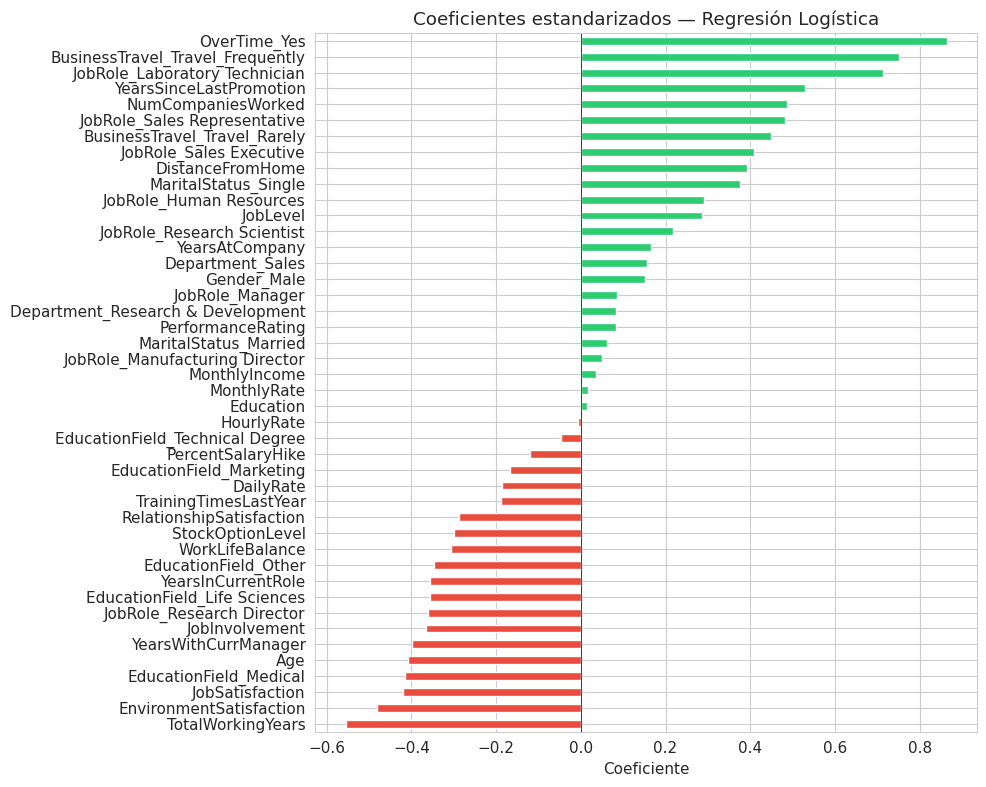

Interpretación:
  → Features que más indican SE FUE (1): ['JobRole_Laboratory Technician', 'BusinessTravel_Travel_Frequently', 'OverTime_Yes']
  → Features que más indican SE QUEDÓ (0): ['TotalWorkingYears', 'EnvironmentSatisfaction', 'JobSatisfaction']


In [92]:
# 5.3 Coeficientes estandarizados
# Obtener los nombres de las features después del One-Hot Encoding
feature_names = X.columns.tolist()

coefs = pd.Series(
    pipe_lr.named_steps['clf'].coef_[0],
    index=feature_names
).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefs]
coefs.plot(kind='barh', ax=ax, color=colors_bar)
ax.set_title('Coeficientes estandarizados — Regresión Logística')
ax.set_xlabel('Coeficiente')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('Interpretación:')
print(f'  → Features que más indican SE FUE (1): {coefs.tail(3).index.tolist()}')
print(f'  → Features que más indican SE QUEDÓ (0): {coefs.head(3).index.tolist()}')

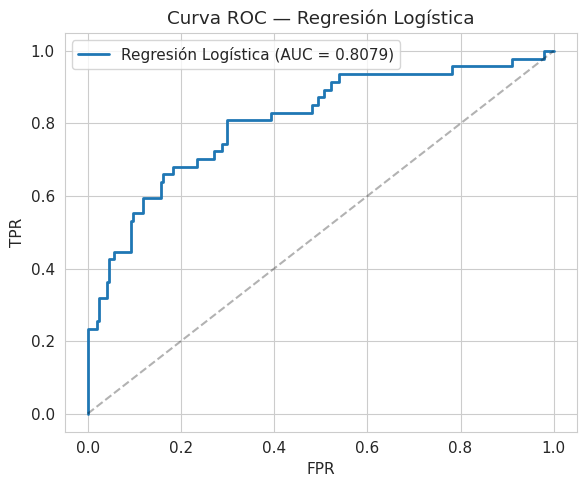

AUC: 0.8079


In [93]:
# 5.4 Curva ROC
fig, ax = plt.subplots(figsize=(6, 5))
auc_lr = plot_roc(pipe_lr, X_test, y_test, 'Regresión Logística', ax)
plt.tight_layout()
plt.show()
print(f'AUC: {auc_lr:.4f}')

MODELO 2


In [94]:

print('MODELO 2: ÁRBOL DE DECISIÓN')


# 6.1 Árbol sin restricciones (para mostrar sobreajuste)
pipe_dt_full = Pipeline([
    ('clf', DecisionTreeClassifier(random_state=42))
])

cv_dt_full = cross_validate(pipe_dt_full, X_train, y_train, cv=skf,
                            scoring=['accuracy', 'f1', 'recall'],
                            return_train_score=True)

print('Árbol de Decisión (SIN restricciones) — CV 5-fold')
print(f'  Train Accuracy: {cv_dt_full["train_accuracy"].mean():.4f}')
print(f'  Test Accuracy:  {cv_dt_full["test_accuracy"].mean():.4f} ± {cv_dt_full["test_accuracy"].std():.4f}')
print(f'  Test F1-Score:  {cv_dt_full["test_f1"].mean():.4f} ± {cv_dt_full["test_f1"].std():.4f}')
print(f'\n Train accuracy ~1.0 indica sobreajuste')

MODELO 2: ÁRBOL DE DECISIÓN
Árbol de Decisión (SIN restricciones) — CV 5-fold
  Train Accuracy: 1.0000
  Test Accuracy:  0.7925 ± 0.0181
  Test F1-Score:  0.3683 ± 0.0908

 Train accuracy ~1.0 indica sobreajuste


In [95]:
# 6.2 Árbol con pre-poda
pipe_dt = Pipeline([
    ('clf', DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

cv_dt = cross_validate(pipe_dt, X_train, y_train, cv=skf,
                       scoring=['accuracy', 'f1', 'recall'],
                       return_train_score=True)

print('Árbol de Decisión (con pre-poda) — CV 5-fold')
print(f'  Train Accuracy: {cv_dt["train_accuracy"].mean():.4f}')
print(f'  Test Accuracy:  {cv_dt["test_accuracy"].mean():.4f} ± {cv_dt["test_accuracy"].std():.4f}')
print(f'  Test F1-Score:  {cv_dt["test_f1"].mean():.4f} ± {cv_dt["test_f1"].std():.4f}')
print(f'  Test Recall:    {cv_dt["test_recall"].mean():.4f} ± {cv_dt["test_recall"].std():.4f}')

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

Árbol de Decisión (con pre-poda) — CV 5-fold
  Train Accuracy: 0.8890
  Test Accuracy:  0.8410 ± 0.0110
  Test F1-Score:  0.3573 ± 0.0761
  Test Recall:    0.2789 ± 0.0774


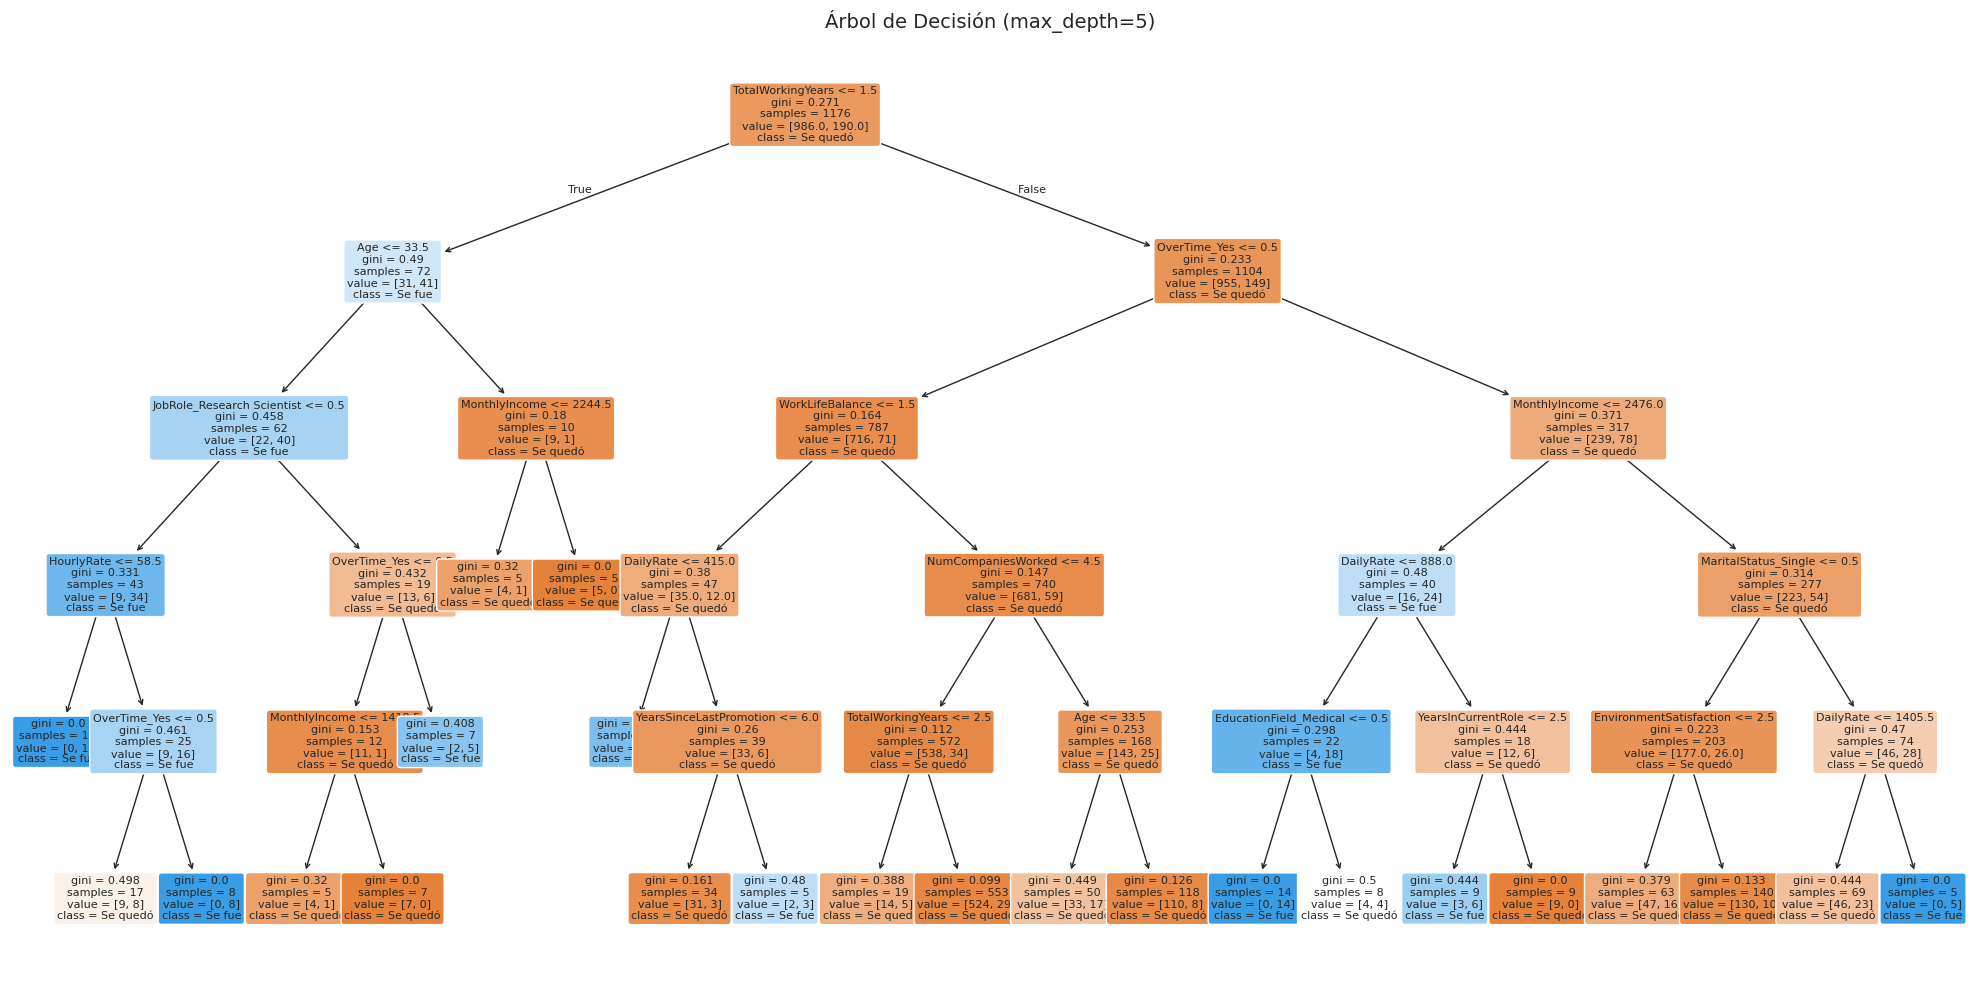

In [96]:
# 6.3 Visualización del árbol podado
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(pipe_dt.named_steps['clf'],
          feature_names=X.columns.tolist(),  # ← Cambio clave: usar X.columns
          class_names=['Se quedó', 'Se fue'],  # ← Cambio: nombres de clases
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Árbol de Decisión (max_depth=5)', fontsize=14)
plt.tight_layout()
plt.show()

=== Árbol de Decisión ===
  Accuracy: 0.8367
  Precision: 0.4737
  Recall: 0.1915
  F1-Score: 0.2727


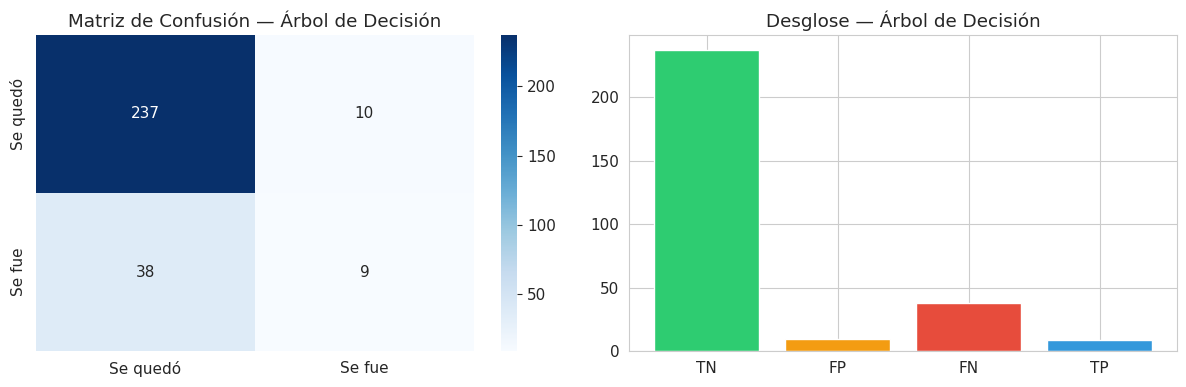

In [97]:
# 6.4 Evaluación completa
metrics_dt = eval_classifier(pipe_dt, X_train, y_train, X_test, y_test, 'Árbol de Decisión')

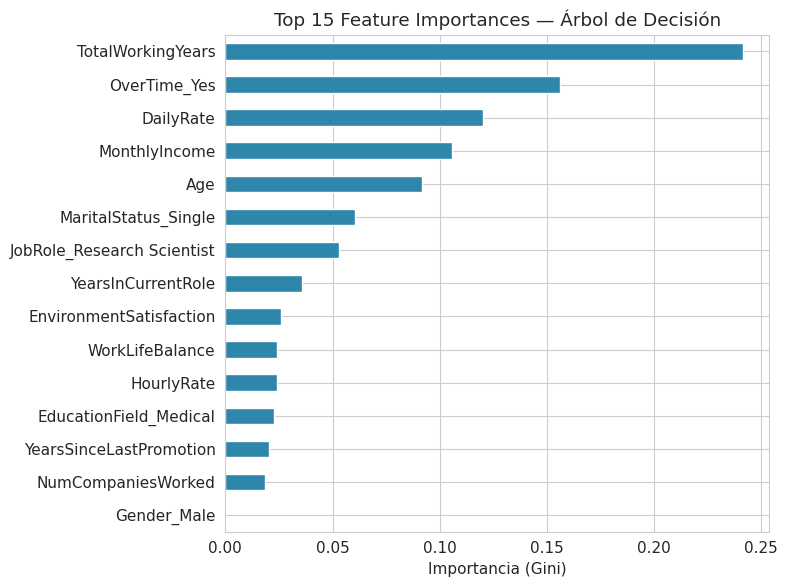

In [98]:
# 6.5 Importancia de features
importances = pd.Series(
    pipe_dt.named_steps['clf'].feature_importances_,
    index=X.columns.tolist()  # ← Cambio: usar X.columns
).sort_values(ascending=True)

# Top 15
top_imp = importances.tail(15)
fig, ax = plt.subplots(figsize=(8, 6))
top_imp.plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_title('Top 15 Feature Importances — Árbol de Decisión')
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

MODELO 3


In [99]:

print('MODELO 3: SUPPORT VECTOR MACHINE (SVM)')


# 7.1 Pipeline SVM con kernel RBF
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', C=1.0, probability=True, random_state=42))
])

cv_svm = cross_validate(pipe_svm, X_train, y_train, cv=skf,
                        scoring=['accuracy', 'f1', 'recall'],
                        return_train_score=True)

print('SVM (RBF, C=1.0) — CV 5-fold')
print(f'  Accuracy:  {cv_svm["test_accuracy"].mean():.4f} ± {cv_svm["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_svm["test_f1"].mean():.4f} ± {cv_svm["test_f1"].std():.4f}')
print(f'  Recall:    {cv_svm["test_recall"].mean():.4f} ± {cv_svm["test_recall"].std():.4f}')

pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)

MODELO 3: SUPPORT VECTOR MACHINE (SVM)
SVM (RBF, C=1.0) — CV 5-fold
  Accuracy:  0.8673 ± 0.0124
  F1-Score:  0.3267 ± 0.1014
  Recall:    0.2053 ± 0.0788


=== SVM (RBF) ===
  Accuracy: 0.8673
  Precision: 0.9000
  Recall: 0.1915
  F1-Score: 0.3158


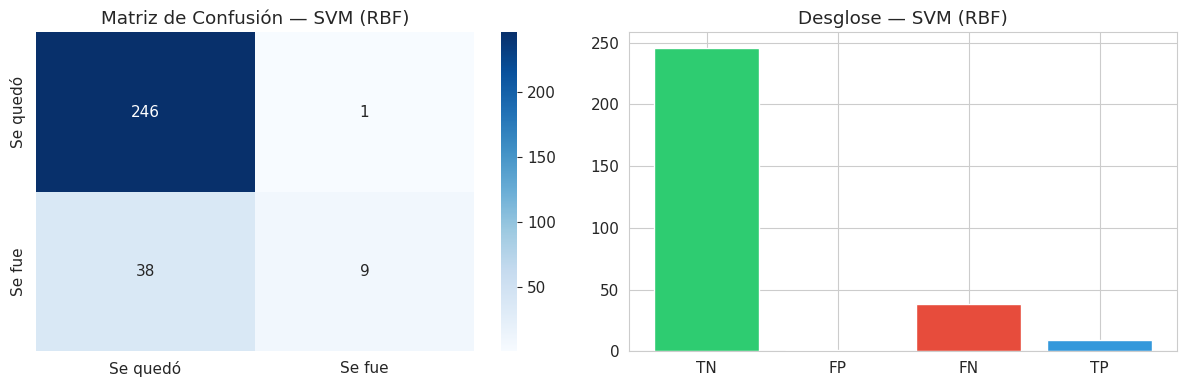

In [100]:
# 7.2 Evaluación completa
metrics_svm = eval_classifier(pipe_svm, X_train, y_train, X_test, y_test, 'SVM (RBF)')

  Kernel linear  : Accuracy = 0.8895
  Kernel rbf     : Accuracy = 0.8673
  Kernel poly    : Accuracy = 0.8606


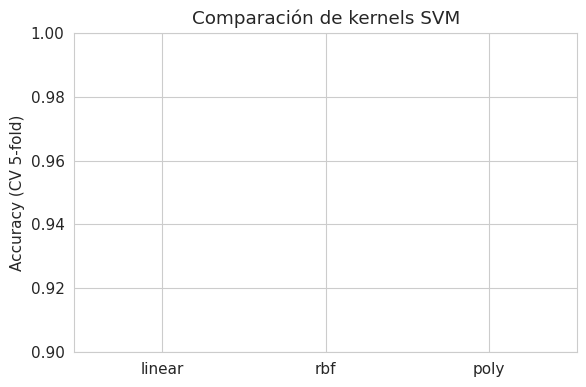

In [101]:
# 7.3 Comparación de kernels
kernels = ['linear', 'rbf', 'poly']
kernel_results = {}

for k in kernels:
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel=k, C=1.0, probability=True, random_state=42))
    ])
    cv_k = cross_validate(pipe_k, X_train, y_train, cv=skf,
                          scoring='accuracy')
    kernel_results[k] = cv_k['test_score'].mean()
    print(f'  Kernel {k:8s}: Accuracy = {kernel_results[k]:.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(kernel_results.keys(), kernel_results.values(), color=['#3498db', '#e74c3c', '#2ecc71'])
ax.set_ylabel('Accuracy (CV 5-fold)')
ax.set_title('Comparación de kernels SVM')
ax.set_ylim(0.9, 1.0)
plt.tight_layout()
plt.show()

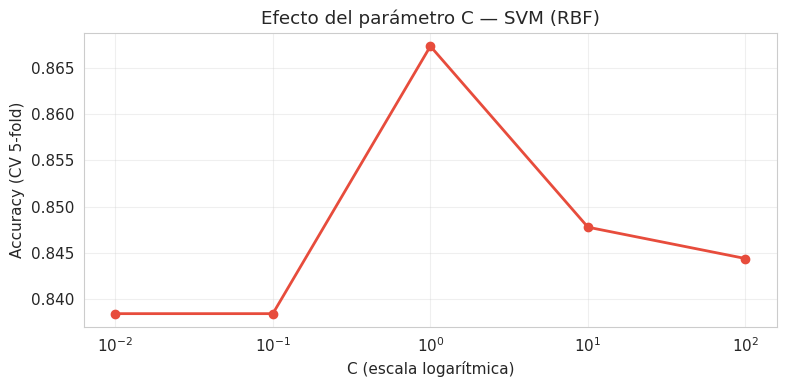


Interpretación:
  C bajo → margen amplio, más errores permitidos (mayor sesgo)
  C alto → margen estrecho, menos errores permitidos (mayor varianza)


In [102]:
# 7.4 Efecto del parámetro C
C_values = [0.01, 0.1, 1, 10, 100]
c_scores = []

for c in C_values:
    pipe_c = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=c, random_state=42))
    ])
    cv_c = cross_validate(pipe_c, X_train, y_train, cv=skf, scoring='accuracy')
    c_scores.append(cv_c['test_score'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(C_values, c_scores, 'o-', color='#e74c3c', linewidth=2)
ax.set_xlabel('C (escala logarítmica)')
ax.set_ylabel('Accuracy (CV 5-fold)')
ax.set_title('Efecto del parámetro C — SVM (RBF)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nInterpretación:')
print('  C bajo → margen amplio, más errores permitidos (mayor sesgo)')
print('  C alto → margen estrecho, menos errores permitidos (mayor varianza)')

MODELO 4


In [103]:

print('MODELO 4: K-NEAREST NEIGHBORS (KNN)')


# 8.1 Pipeline KNN
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=5))
])

cv_knn = cross_validate(pipe_knn, X_train, y_train, cv=skf,
                        scoring=['accuracy', 'f1', 'recall'],
                        return_train_score=True)

print('KNN (K=5) — CV 5-fold')
print(f'  Accuracy:  {cv_knn["test_accuracy"].mean():.4f} ± {cv_knn["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_knn["test_f1"].mean():.4f} ± {cv_knn["test_f1"].std():.4f}')
print(f'  Recall:    {cv_knn["test_recall"].mean():.4f} ± {cv_knn["test_recall"].std():.4f}')

pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)

MODELO 4: K-NEAREST NEIGHBORS (KNN)
KNN (K=5) — CV 5-fold
  Accuracy:  0.8495 ± 0.0138
  F1-Score:  0.2444 ± 0.0861
  Recall:    0.1526 ± 0.0586


=== KNN (K=5) ===
  Accuracy: 0.8469
  Precision: 0.6250
  Recall: 0.1064
  F1-Score: 0.1818


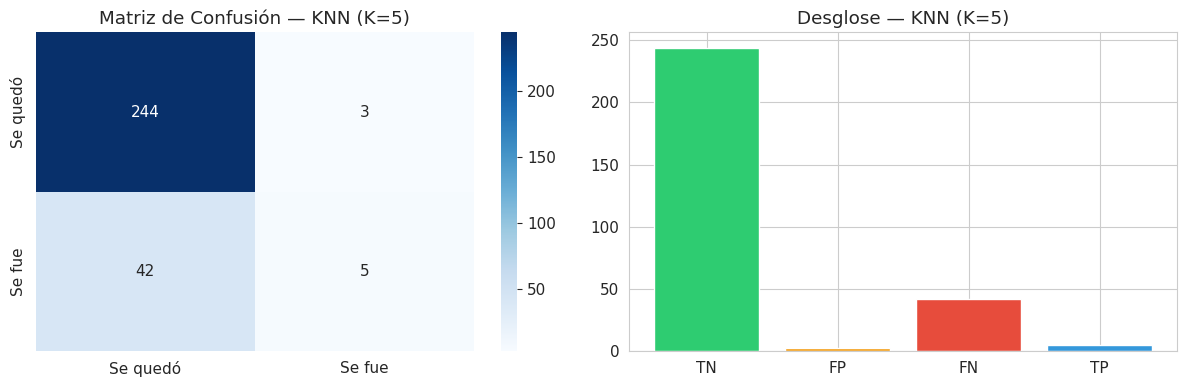

In [104]:
# 8.2 Evaluación completa
metrics_knn = eval_classifier(pipe_knn, X_train, y_train, X_test, y_test, 'KNN (K=5)')

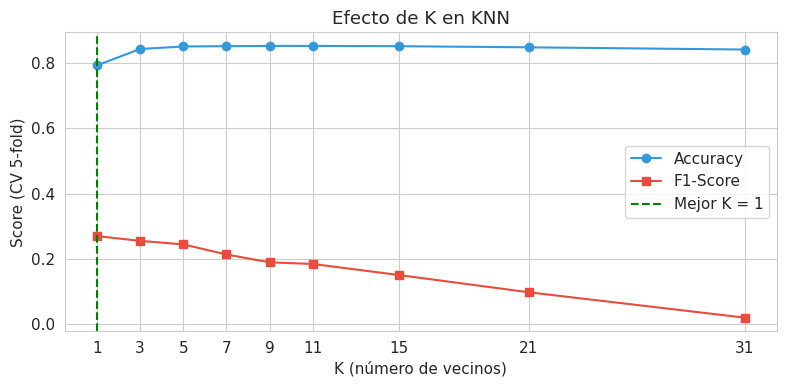

Mejor K por F1: 1
K empírico (√1176): 34


In [105]:
# 8.3 Búsqueda del K óptimo
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]
k_scores_acc = []
k_scores_f1 = []

for k in k_values:
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    cv_k = cross_validate(pipe_k, X_train, y_train, cv=skf,
                          scoring=['accuracy', 'f1'])
    k_scores_acc.append(cv_k['test_accuracy'].mean())
    k_scores_f1.append(cv_k['test_f1'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_values, k_scores_acc, 'o-', label='Accuracy', color='#3498db')
ax.plot(k_values, k_scores_f1, 's-', label='F1-Score', color='#e74c3c')
best_k = k_values[np.argmax(k_scores_f1)]
ax.axvline(x=best_k, color='green', linestyle='--', label=f'Mejor K = {best_k}')
ax.set_xlabel('K (número de vecinos)')
ax.set_ylabel('Score (CV 5-fold)')
ax.set_title('Efecto de K en KNN')
ax.legend()
ax.set_xticks(k_values)
plt.tight_layout()
plt.show()

print(f'Mejor K por F1: {best_k}')
print(f'K empírico (√{len(X_train)}): {int(np.sqrt(len(X_train)))}')

In [106]:
# 8.4 Comparación de métricas de distancia
distances = ['euclidean', 'manhattan', 'minkowski']
dist_results = {}

for d in distances:
    p_val = 3 if d == 'minkowski' else 2
    pipe_d = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5, metric=d, p=p_val))
    ])
    cv_d = cross_validate(pipe_d, X_train, y_train, cv=skf, scoring='f1')
    dist_results[d] = cv_d['test_score'].mean()
    label = f'{d} (p={p_val})' if d == 'minkowski' else d
    print(f'  Distancia {label:20s}: F1 = {dist_results[d]:.4f}')

  Distancia euclidean           : F1 = 0.2444
  Distancia manhattan           : F1 = 0.2431
  Distancia minkowski (p=3)     : F1 = 0.2386


MODELO 5

MODELO 5: RANDOM FOREST (Modelo adicional del Ejercicio 3)
Random Forest — CV 5-fold
  Accuracy:  0.8656 ± 0.0103
  F1-Score:  0.3262 ± 0.0792
  Recall:    0.2053 ± 0.0609
=== Random Forest ===
  Accuracy: 0.8367
  Precision: 0.4545
  Recall: 0.1064
  F1-Score: 0.1724


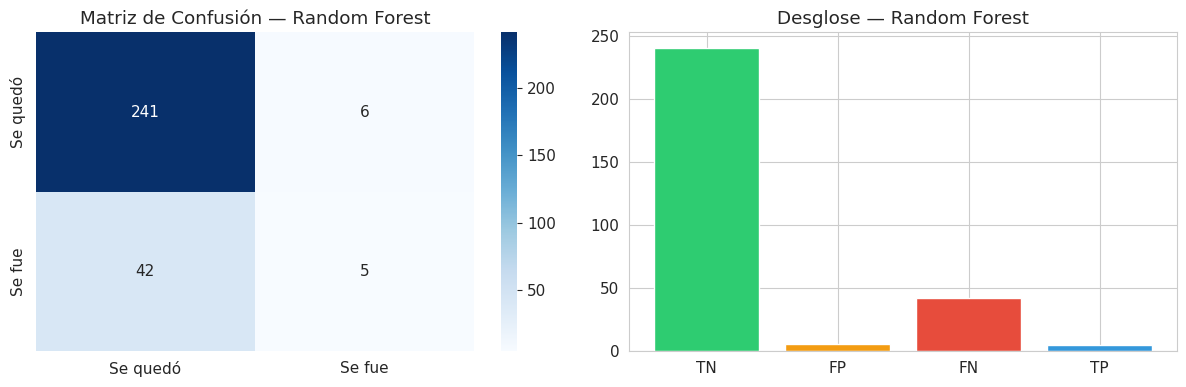

In [107]:

print('MODELO 5: RANDOM FOREST (Modelo adicional del Ejercicio 3)')


# Pipeline Random Forest
pipe_rf = Pipeline([
    ('clf', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))
])

# Validación cruzada
cv_rf = cross_validate(pipe_rf, X_train, y_train, cv=skf,
                       scoring=['accuracy', 'f1', 'recall'],
                       return_train_score=True)

print('Random Forest — CV 5-fold')
print(f'  Accuracy:  {cv_rf["test_accuracy"].mean():.4f} ± {cv_rf["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_rf["test_f1"].mean():.4f} ± {cv_rf["test_f1"].std():.4f}')
print(f'  Recall:    {cv_rf["test_recall"].mean():.4f} ± {cv_rf["test_recall"].std():.4f}')

# Entrenar modelo final
pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)

# Evaluación completa
metrics_rf = eval_classifier(pipe_rf, X_train, y_train, X_test, y_test, 'Random Forest')

Comparación final de modelos

In [108]:

print('COMPARACIÓN FINAL DE MODELOS (4 del curso + 1 adicional)')


# 9.1 Tabla resumen de métricas (incluyendo Random Forest)
all_models = {
    'Regresión Logística': pipe_lr,
    'Árbol de Decisión': pipe_dt,
    'SVM (RBF)': pipe_svm,
    'KNN (K=5)': pipe_knn,
    'Random Forest': pipe_rf  # ← Modelo adicional del Ejercicio 3
}

all_metrics = {}
for name, model in all_models.items():
    y_pred = model.predict(X_test)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc_val = auc(fpr, tpr)
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test)
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc_val = auc(fpr, tpr)
    else:
        roc_auc_val = None

    all_metrics[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_val
    }

metrics_df = pd.DataFrame(all_metrics).T.round(4)
print('=== Tabla comparativa de métricas (Test Set) ===')
display(metrics_df)

COMPARACIÓN FINAL DE MODELOS (4 del curso + 1 adicional)
=== Tabla comparativa de métricas (Test Set) ===


,Accuracy,Precision,Recall,F1-Score,AUC
Regresión Logística,0.8605,0.6154,0.3404,0.4384,0.8079
Árbol de Decisión,0.8367,0.4737,0.1915,0.2727,0.6842
SVM (RBF),0.8673,0.9000,0.1915,0.3158,0.8129
KNN (K=5),0.8469,0.6250,0.1064,0.1818,0.6361
Random Forest,0.8367,0.4545,0.1064,0.1724,0.7870


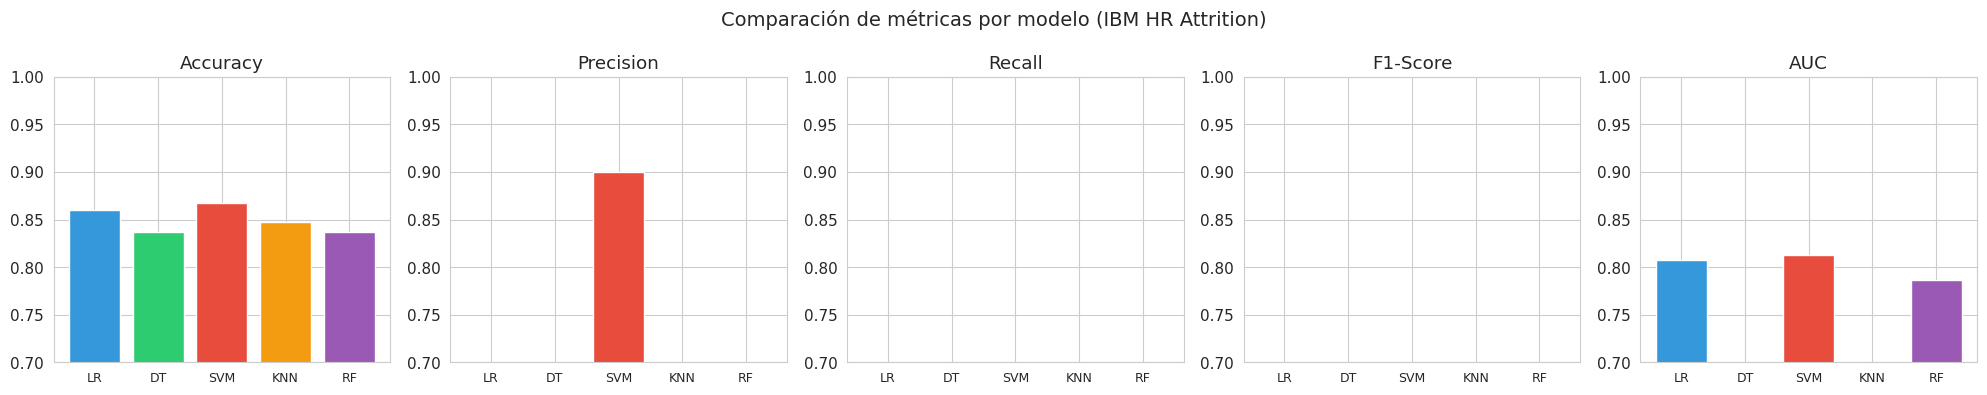

In [109]:
# 9.2 Gráfico de barras comparativo
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
colors_models = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']  # 5 colores para 5 modelos

for i, metric in enumerate(metric_names):
    values = [all_metrics[m][metric] for m in all_models]
    axes[i].bar(range(len(values)), values, color=colors_models)
    axes[i].set_title(metric)
    axes[i].set_ylim(0.7, 1.0)  # Ajustado para el rango realista de tu dataset
    axes[i].set_xticks(range(len(values)))
    axes[i].set_xticklabels(['LR', 'DT', 'SVM', 'KNN', 'RF'], fontsize=9)  # RF = Random Forest

plt.suptitle('Comparación de métricas por modelo (IBM HR Attrition)', fontsize=14)
plt.tight_layout()
plt.show()

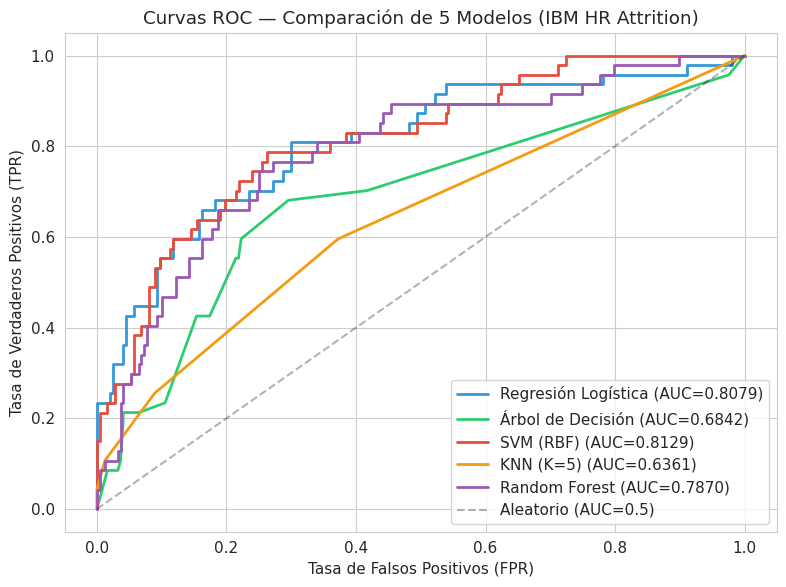

In [110]:
# 9.3 Curvas ROC superpuestas
fig, ax = plt.subplots(figsize=(8, 6))

for (name, model), color in zip(all_models.items(), colors_models):
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_test)
    else:
        continue
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, color=color,
            label=f'{name} (AUC={roc_auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Aleatorio (AUC=0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curvas ROC — Comparación de 5 Modelos (IBM HR Attrition)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [111]:
# 9.4 Matriz de selección (adaptada al contexto de RR.HH.)
selection_matrix = pd.DataFrame({
    'Modelo': ['Reg. Logística', 'Árbol de Decisión', 'SVM (RBF)', 'KNN', 'Random Forest'],
    'Precisión predictiva': ['★★★★☆', '★★★☆☆', '★★★★☆', '★★★☆☆', '★★★★★'],
    'Velocidad (train+pred)': ['★★★★★', '★★★★★', '★★☆☆☆', '★★★★☆', '★★★☆☆'],
    'Interpretabilidad': ['★★★★★', '★★★★★', '★★☆☆☆', '★★★☆☆', '★★★☆☆'],
    'Manejo de no-linealidad': ['★★☆☆☆', '★★★★☆', '★★★★★', '★★★☆☆', '★★★★★']
}).set_index('Modelo')

print('=== Matriz de Selección de Modelos (Contexto RR.HH.) ===')
display(selection_matrix)

print('\n CONCLUSIÓN FINAL:')
print('Para predecir la rotación de empleados, el "Recall" de la clase "Se fue (1)" es la métrica más importante.')
mejor_recall = metrics_df['Recall'].idxmax()
print(f' El modelo con mejor Recall en el conjunto de prueba es: {mejor_recall}')

=== Matriz de Selección de Modelos (Contexto RR.HH.) ===


,Precisión predictiva,Velocidad (train+pred),Interpretabilidad,Manejo de no-linealidad
Modelo,,,,
Reg. Logística,★★★★☆,★★★★★,★★★★★,★★☆☆☆
Árbol de Decisión,★★★☆☆,★★★★★,★★★★★,★★★★☆
SVM (RBF),★★★★☆,★★☆☆☆,★★☆☆☆,★★★★★
KNN,★★★☆☆,★★★★☆,★★★☆☆,★★★☆☆
Random Forest,★★★★★,★★★☆☆,★★★☆☆,★★★★★



 CONCLUSIÓN FINAL:
Para predecir la rotación de empleados, el "Recall" de la clase "Se fue (1)" es la métrica más importante.
 El modelo con mejor Recall en el conjunto de prueba es: Regresión Logística


OPTIMIZACIÓN CON GRIDSEARCHCV'

In [115]:


print('OPTIMIZACIÓN DE HIPERPARÁMETROS CON GRIDSEARCHCV')


from sklearn.model_selection import GridSearchCV

# Diccionario con los modelos y sus grillas de parámetros (sugeridas por el docente)
param_grids = {
    'Regresión Logística': {
        'model': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
        'params': {'clf__C': [0.01, 0.1, 1, 10, 100]}
    },
    'Árbol de Decisión': {
        'model': Pipeline([('clf', DecisionTreeClassifier(random_state=42))]),
        'params': {'clf__max_depth': [3, 5, 7, 10], 'clf__min_samples_leaf': [1, 5, 10]}
    },
    'SVM (RBF)': {
        'model': Pipeline([('scaler', StandardScaler()), ('clf', SVC(probability=True, random_state=42))]),
        'params': {'clf__C': [0.1, 1, 10], 'clf__gamma': [0.001, 0.01, 0.1]}
    },
    'KNN': {
        'model': Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier())]),
        'params': {'clf__n_neighbors': [3, 5, 9, 15], 'clf__weights': ['uniform', 'distance']}
    },
    'Random Forest': {
        'model': Pipeline([('clf', RandomForestClassifier(random_state=42, n_jobs=-1))]),
        'params': {'clf__n_estimators': [50, 100], 'clf__max_depth': [5, 10, None]}
    }
}

best_models = {}
print('\n Iniciando búsqueda exhaustiva (esto puede tomar 2-3 minutos)...\n')

for name, config in param_grids.items():
    print(f'Optimizando {name}...')
    grid = GridSearchCV(config['model'], config['params'], cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    print(f'  Mejores params: {grid.best_params_} | Mejor F1-Score: {grid.best_score_:.4f}\n')

print(' ¡Optimización completada para los 5 modelos!')

OPTIMIZACIÓN DE HIPERPARÁMETROS CON GRIDSEARCHCV

 Iniciando búsqueda exhaustiva (esto puede tomar 2-3 minutos)...

Optimizando Regresión Logística...
  Mejores params: {'clf__C': 10} | Mejor F1-Score: 0.5514

Optimizando Árbol de Decisión...
  Mejores params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 5} | Mejor F1-Score: 0.3279

Optimizando SVM (RBF)...
  Mejores params: {'clf__C': 10, 'clf__gamma': 0.01} | Mejor F1-Score: 0.4654

Optimizando KNN...
  Mejores params: {'clf__n_neighbors': 3, 'clf__weights': 'uniform'} | Mejor F1-Score: 0.3250

Optimizando Random Forest...
  Mejores params: {'clf__max_depth': None, 'clf__n_estimators': 100} | Mejor F1-Score: 0.3176

 ¡Optimización completada para los 5 modelos!


MANEJO DE DESBALANCE

In [117]:


print(' MANEJO DE DESBALANCE (class_weight y SMOTE)')


print('\n1️ COMPARACIÓN DE RECALL (Clase Minoritaria: "Se fue = 1") CON Y SIN BALANCEO:')
print('-' * 80)
print(f"{'Modelo':<25} | {'Recall Normal':<15} | {'Recall con Balanced':<15}")
print('-' * 80)

# Modelos base (ya entrenados) vs Modelos con class_weight='balanced'
models_to_test = {
    'Regresión Logística': (pipe_lr, Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))])),
    'Árbol de Decisión': (pipe_dt, Pipeline([('clf', DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42))])),
    'SVM (RBF)': (pipe_svm, Pipeline([('scaler', StandardScaler()), ('clf', SVC(class_weight='balanced', kernel='rbf', C=1.0, probability=True, random_state=42))])),
    'KNN': (pipe_knn, pipe_knn) # KNN no tiene class_weight, se deja igual como referencia
}

for name, (base_model, balanced_model) in models_to_test.items():
    # Recall normal
    y_pred_base = base_model.predict(X_test)
    recall_base = recall_score(y_test, y_pred_base, pos_label=1, zero_division=0)

    # Recall con balanceo
    balanced_model.fit(X_train, y_train)
    y_pred_bal = balanced_model.predict(X_test)
    recall_bal = recall_score(y_test, y_pred_bal, pos_label=1, zero_division=0)

    print(f"{name:<25} | {recall_base:<15.4f} | {recall_bal:<15.4f}")

print('\n2️ APLICACIÓN DE SMOTE (Sintetic Minority Over-sampling Technique):')
try:
    from imblearn.over_sampling import SMOTE

    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    print(f'   • Tamaño de X_train original: {X_train.shape[0]} muestras')
    print(f'   • Tamaño de X_train con SMOTE:  {X_train_smote.shape[0]} muestras (Clases 100% balanceadas)')

    # Entrenar un modelo con datos SMOTE
    lr_smote = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=42))])
    lr_smote.fit(X_train_smote, y_train_smote)

    y_pred_smote = lr_smote.predict(X_test)
    recall_smote = recall_score(y_test, y_pred_smote, pos_label=1, zero_division=0)
    print(f'   → Recall de Regresión Logística con SMOTE: {recall_smote:.4f}')

except ImportError:
    print('    SMOTE no disponible. Para instalarlo, ejecuta en una celda: !pip install imbalanced-learn')

print('\n CONCLUSIÓN')
print('El uso de class_weight="balanced" o SMOTE generalmente incrementa el Recall de la clase minoritaria ("Se fue"),')
print('lo cual es crucial en RR.HH. para no dejar escapar a empleados en riesgo de renunciar, aunque pueda bajar ligeramente el Accuracy general.')

 MANEJO DE DESBALANCE (class_weight y SMOTE)

1️ COMPARACIÓN DE RECALL (Clase Minoritaria: "Se fue = 1") CON Y SIN BALANCEO:
--------------------------------------------------------------------------------
Modelo                    | Recall Normal   | Recall con Balanced
--------------------------------------------------------------------------------
Regresión Logística       | 0.3404          | 0.6170         
Árbol de Decisión         | 0.1915          | 0.5319         
SVM (RBF)                 | 0.1915          | 0.5319         
KNN                       | 0.1064          | 0.1064         

2️ APLICACIÓN DE SMOTE (Sintetic Minority Over-sampling Technique):
   • Tamaño de X_train original: 1176 muestras
   • Tamaño de X_train con SMOTE:  1972 muestras (Clases 100% balanceadas)
   → Recall de Regresión Logística con SMOTE: 0.4255

 CONCLUSIÓN
El uso de class_weight="balanced" o SMOTE generalmente incrementa el Recall de la clase minoritaria ("Se fue"),
lo cual es crucial en RR.HH. p